# Bigmart Sales Project

### Problem Statement

The data scientists at BigMart have collected sales data for 1559 products across 10 stores in different cities for the year 2013. Now each product has certain attributes that sets it apart from other products.

### Dataset Description

The data scientists at BigMart have collected 2013 sales data for 1559 products across 10 stores in different cities. Also, certain attributes of each product and store have been defined. 

Item_Identifier               

Item_Weight                   

Item_Fat_Content               

Item_Visibility                

Item_Type                       

Item_MRP                        

Outlet_Identifier               

Outlet_Establishment_Year       

Outlet_Size                  

Outlet_Location_Type            

Outlet_Type

### Goal

The objective is to create a model that can predict the sales per product for each store. That means our Target variable is sale that is continues variable so in this project we can use The Regression Algorithm to predict a model. Using this model, BigMart will try to understand the properties of products and stores which play a key role in increasing sales.

### Importing Libraries

In [780]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, StandardScaler,\
OneHotEncoder
from sklearn.linear_model import LinearRegression

### Data Loading And Initial Analysis

In [781]:
#Load Datasets
train=pd.read_csv('Train.csv')
test=pd.read_csv('Test.csv')

In [782]:
#info of the train dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [783]:
#info of the test dataset
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


We can combine both datasets for ease of preprocessing and later we can separate it again.

In [784]:
# first create a new column in test dataset to identify it in combined dataset
test['source']='test'

In [785]:
# Now we will combine both datasets
df=pd.concat([train,test],ignore_index=True)
df['source'].fillna('train', inplace=True)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,train
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,train
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,train
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,train
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,train


In [786]:
# info of the combined dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  object 
 1   Item_Weight                11765 non-null  float64
 2   Item_Fat_Content           14204 non-null  object 
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  object 
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  object 
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                10188 non-null  object 
 9   Outlet_Location_Type       14204 non-null  object 
 10  Outlet_Type                14204 non-null  object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  source                     14204 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usag

In [787]:
df.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
14199,FDB58,10.5,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1,NaN,test
14200,FDD47,7.6,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2,NaN,test
14201,NCO17,10.0,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,NaN,Tier 2,Supermarket Type1,NaN,test
14202,FDJ26,15.3,Regular,0.000000,Canned,214.6218,OUT017,2007,NaN,Tier 2,Supermarket Type1,NaN,test
14203,FDU37,9.5,Regular,0.104720,Canned,79.7960,OUT045,2002,NaN,Tier 2,Supermarket Type1,NaN,test


In [788]:
# Lets check for duplicate rows
print(df.duplicated().sum())

0


In [789]:
# check duplicate combination of Item_Identifier and Outlet_Identifier
print(df.duplicated
      (subset=['Item_Identifier', 'Outlet_Identifier']).sum())

0


In [790]:
# checking for null values
df.drop(['source', 'Item_Outlet_Sales'], axis=1).isnull().sum()

Item_Identifier                 0
Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [791]:
# Value count of all categorical variables
category=df.select_dtypes(include='object').columns.\
    drop(['Item_Identifier','source'])
for col in category:
    print(df[col].value_counts())
    print('-----------------------------')

Item_Fat_Content
Low Fat    8485
Regular    4824
LF          522
reg         195
low fat     178
Name: count, dtype: int64
-----------------------------
Item_Type
Fruits and Vegetables    2013
Snack Foods              1989
Household                1548
Frozen Foods             1426
Dairy                    1136
Baking Goods             1086
Canned                   1084
Health and Hygiene        858
Meat                      736
Soft Drinks               726
Breads                    416
Hard Drinks               362
Others                    280
Starchy Foods             269
Breakfast                 186
Seafood                    89
Name: count, dtype: int64
-----------------------------
Outlet_Identifier
OUT027    1559
OUT013    1553
OUT035    1550
OUT049    1550
OUT046    1550
OUT045    1548
OUT018    1546
OUT017    1543
OUT010     925
OUT019     880
Name: count, dtype: int64
-----------------------------
Outlet_Size
Medium    4655
Small     3980
High      1553
Name: count, dtype: 

In [792]:
# Values in Outlet_Establishment_Year
df['Outlet_Establishment_Year'].unique().tolist()

[1999, 2009, 1998, 1987, 1985, 2002, 2007, 1997, 2004]

- 'Item_Fat_Content' feature has only 2 categories but its written in different ways. These needs to be fixed while converting it to numerical format.

- 'Item_Weight' and 'Outlet_Size' features has missing values. The count of missing values it too high so we can't drop rows since it can cause heavy data loss.

- Dataset doesnot have duplicate columns.

- 'Item_Identifier' and 'Outlet_Identifier' are IDs and their combination is unique so they are not useful for prediction.

- 'Outlet_Establishment_Year' feature has only 9 values which can be converted into Age.

### Data Cleaning

In [793]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  object 
 1   Item_Weight                11765 non-null  float64
 2   Item_Fat_Content           14204 non-null  object 
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  object 
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  object 
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                10188 non-null  object 
 9   Outlet_Location_Type       14204 non-null  object 
 10  Outlet_Type                14204 non-null  object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  source                     14204 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usag

In [794]:
# Drop columns which are not useful for model building
df.drop(['Item_Identifier', 'Outlet_Identifier'],\
         axis=1, inplace=True)

In [795]:
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380,train
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228,train
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700,train
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,NaN,Tier 3,Grocery Store,732.3800,train
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052,train


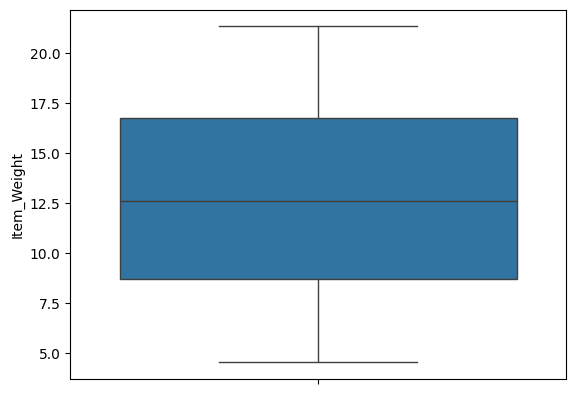

In [796]:
# Check the outliers in 'Item_Weight'
sns.boxplot(df['Item_Weight'])
plt.show()

In [797]:
# Filling null values in Item_Weight and Outlet_Size columns with mean value and mode value respectively
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)

In [798]:
# Fixing the values in Item_Fat_Content column
df['Item_Fat_Content']=df['Item_Fat_Content']\
    .replace({'LF':'Low Fat', 'reg':'Regular', 'low fat':'Low Fat'})

# Checking the values in Item_Fat_Content column
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    9185
Regular    5019
Name: count, dtype: int64

### EDA

In [799]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                14204 non-null  float64
 1   Item_Fat_Content           14204 non-null  object 
 2   Item_Visibility            14204 non-null  float64
 3   Item_Type                  14204 non-null  object 
 4   Item_MRP                   14204 non-null  float64
 5   Outlet_Establishment_Year  14204 non-null  int64  
 6   Outlet_Size                14204 non-null  object 
 7   Outlet_Location_Type       14204 non-null  object 
 8   Outlet_Type                14204 non-null  object 
 9   Item_Outlet_Sales          8523 non-null   float64
 10  source                     14204 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 1.2+ MB


In [800]:
# check skewness in all numerical variables
numerical=['Item_Weight', 'Item_Visibility', 'Item_MRP']
for col in numerical:
    print(col, 'skewness: ', df[col].skew())

Item_Weight skewness:  0.11131389957020878
Item_Visibility skewness:  1.1951751774587882
Item_MRP skewness:  0.13072836040225866


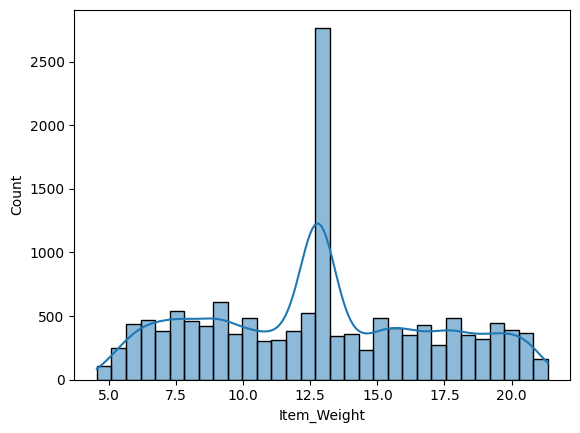

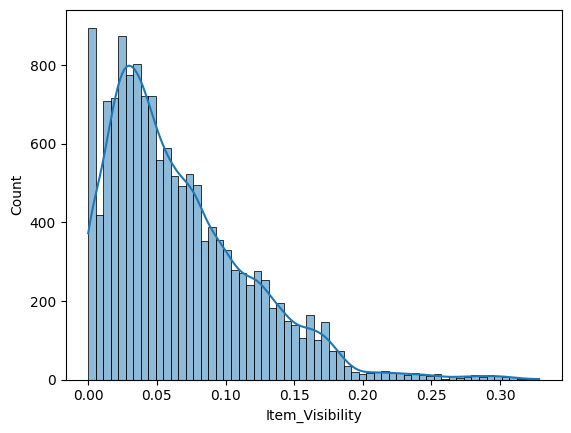

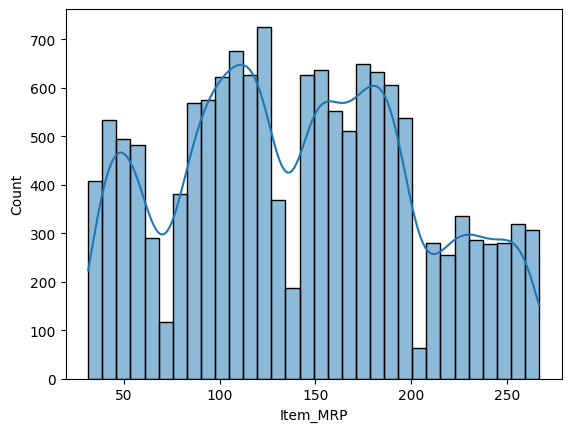

In [801]:
# Find Distribution of Numerical Variables
for col in numerical:
    sns.histplot(df[col], kde=True)
    plt.show()

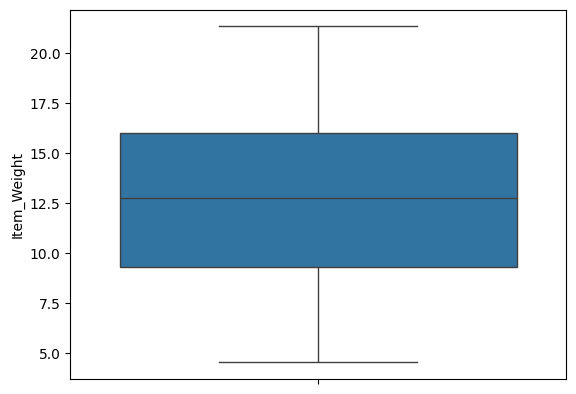

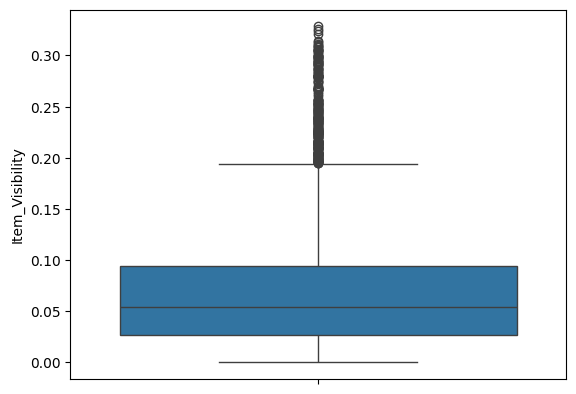

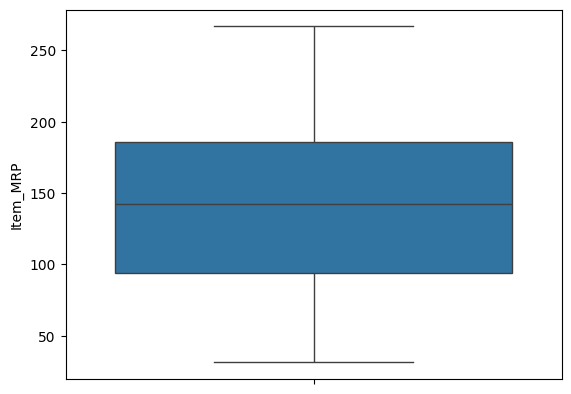

In [802]:
# Check for outliers in all numerical variables
for col in numerical:
    sns.boxplot(df[col])
    plt.show()

'Item_Visibility' has some skewness and outliers.

In [803]:
df[numerical + ['Item_Outlet_Sales']].corr()['Item_Outlet_Sales'].sort_values(ascending=False).drop('Item_Outlet_Sales')

Item_MRP           0.567574
Item_Weight        0.011083
Item_Visibility   -0.128625
Name: Item_Outlet_Sales, dtype: float64

<Axes: ylabel='Item_Outlet_Sales'>

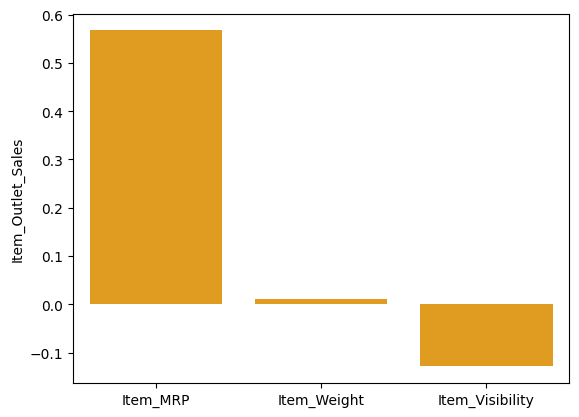

In [804]:
# Correlation between numerical variables and target variable
sns.barplot(df[numerical + ['Item_Outlet_Sales']]\
            .corr()['Item_Outlet_Sales']\
            .sort_values(ascending=False)\
            .drop('Item_Outlet_Sales'), color='orange')

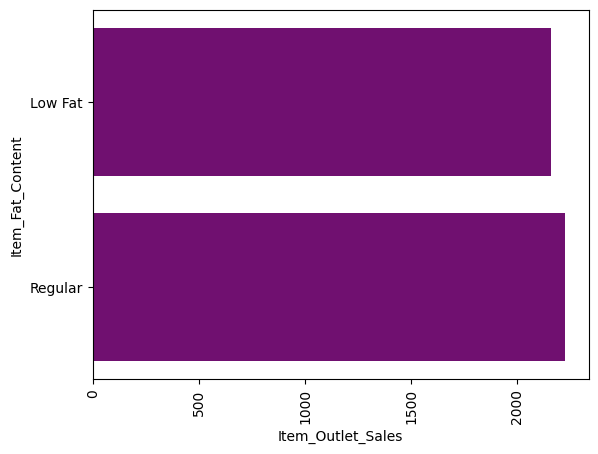

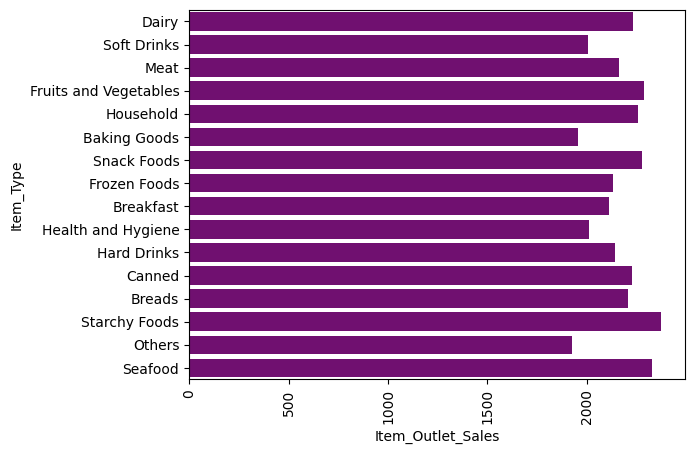

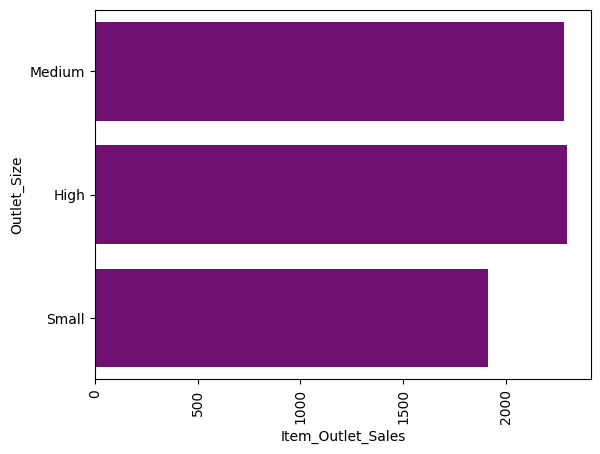

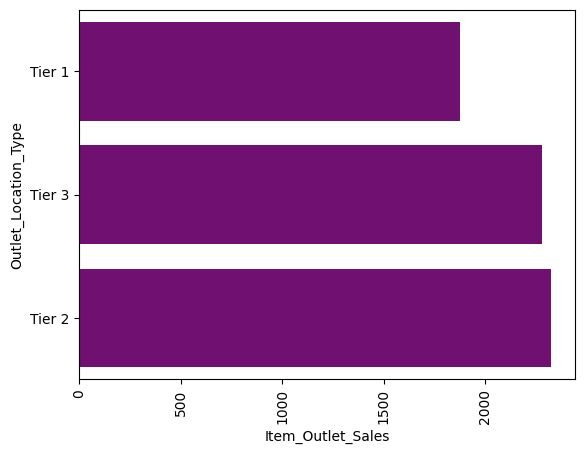

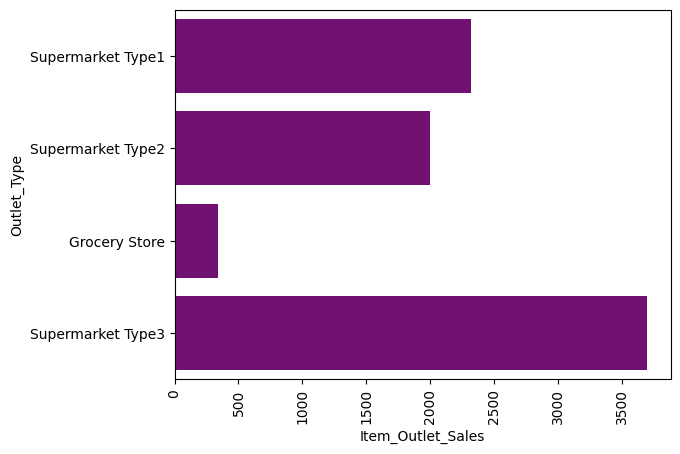

In [805]:
# Total sales across all category features
cat_col=['Item_Fat_Content', 'Item_Type',\
        'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
for col in cat_col:
    sns.barplot(x='Item_Outlet_Sales', y=col, data=df, errorbar=None,
                color='purple')
    plt.xticks(rotation=90)
    plt.show()

### Preprocessing

In [806]:
# fixing the skewness in Item_Visibility column by applying Power Transformation
pt=PowerTransformer()
df['Item_Visibility']=pt.fit_transform(df[['Item_Visibility']])

# check skewness in Item_Visibility column after transformation
print('Item_Visibility skewness: ', df['Item_Visibility'].skew())

Item_Visibility skewness:  0.12133160983966018


<Axes: ylabel='Item_Visibility'>

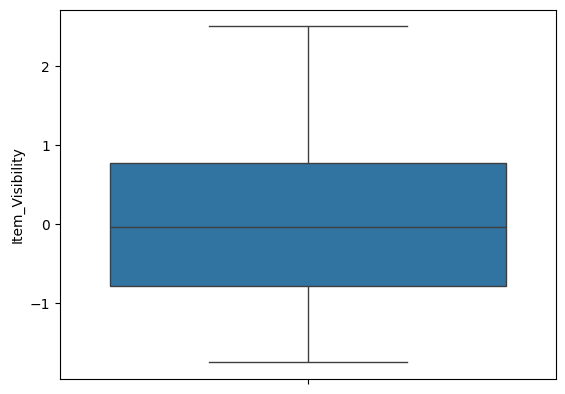

In [807]:
# boxplot of Item_Visibility column after transformation
sns.boxplot(df['Item_Visibility'])

In [808]:
# Changing the Outlet_Establishment_Year column to 'Outlet_Age'
df['Outlet_Age']=2026-df['Outlet_Establishment_Year']

# Drop the Outlet_Establishment_Year column
df.drop('Outlet_Establishment_Year', axis=1, inplace=True)

In [809]:
# select all numerical features
numerical=['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']

In [810]:
# Scaling all the numerical variables using Standard Scaler
scaler=StandardScaler()
df[numerical]=scaler.fit_transform(df[numerical])

# Check the data after scaling
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source,Outlet_Age
0,-0.824939,Low Fat,-1.149234,Dairy,1.752511,Medium,Tier 1,Supermarket Type1,3735.1380,train,-0.139681
1,-1.623224,Regular,-1.038844,Soft Drinks,-1.493696,Medium,Tier 3,Supermarket Type2,443.4228,train,-1.334228
2,1.111729,Low Fat,-1.124586,Meat,0.009874,Medium,Tier 1,Supermarket Type1,2097.2700,train,-0.139681
3,1.513233,Regular,-1.751417,Fruits and Vegetables,0.661838,Medium,Tier 3,Grocery Store,732.3800,train,-0.020226
4,-0.912325,Low Fat,-1.751417,Household,-1.403623,High,Tier 3,Supermarket Type1,994.7052,train,1.293777


In [811]:
# Encoding some of the categorical variables
df['Item_Fat_Content']=df['Item_Fat_Content']\
    .map({'Low Fat':0, 'Regular':1})

df['Outlet_Size']=df['Outlet_Size']\
    .map({'Small':0, 'Medium':1, 'High':2})

df['Outlet_Location_Type']=df['Outlet_Location_Type']\
    .map({'Tier 1':2, 'Tier 2':1, 'Tier 3':0})

df['Outlet_Type']=df['Outlet_Type']\
    .map({'Grocery Store':0, 'Supermarket Type1':1,
          'Supermarket Type2':2, 'Supermarket Type3':3})

df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source,Outlet_Age
0,-0.824939,0,-1.149234,Dairy,1.752511,1,2,1,3735.1380,train,-0.139681
1,-1.623224,1,-1.038844,Soft Drinks,-1.493696,1,0,2,443.4228,train,-1.334228
2,1.111729,0,-1.124586,Meat,0.009874,1,2,1,2097.2700,train,-0.139681
3,1.513233,1,-1.751417,Fruits and Vegetables,0.661838,1,0,0,732.3800,train,-0.020226
4,-0.912325,0,-1.751417,Household,-1.403623,2,0,1,994.7052,train,1.293777


In [812]:
# One hot encoding of Item_Type column
ohe=OneHotEncoder(sparse_output=False, dtype=int)
item_type_encoded=ohe.fit_transform(df[['Item_Type']])
item_type_encoded_df=\
    pd.DataFrame(item_type_encoded, \
                columns=ohe.get_feature_names_out(['Item_Type']))

# Concatenate the one hot encoded columns with the original dataframe
df=pd.concat([df, item_type_encoded_df], axis=1)

# Drop the original Item_Type column
df.drop('Item_Type', axis=1, inplace=True)

In [813]:
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source,Outlet_Age,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,-0.824939,0,-1.149234,1.752511,1,2,1,3735.1380,train,-0.139681,...,0,0,0,0,0,0,0,0,0,0
1,-1.623224,1,-1.038844,-1.493696,1,0,2,443.4228,train,-1.334228,...,0,0,0,0,0,0,0,0,1,0
2,1.111729,0,-1.124586,0.009874,1,2,1,2097.2700,train,-0.139681,...,0,0,0,0,1,0,0,0,0,0
3,1.513233,1,-1.751417,0.661838,1,0,0,732.3800,train,-0.020226,...,1,0,0,0,0,0,0,0,0,0
4,-0.912325,0,-1.751417,-1.403623,2,0,1,994.7052,train,1.293777,...,0,0,0,1,0,0,0,0,0,0


In [814]:
# split the combined dataset back into train and test datasets
test_df=df[df['source']=='test'].drop(['source','Item_Outlet_Sales'], axis=1)

In [815]:
test_df.reset_index(drop=True, inplace=True)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Weight                      5681 non-null   float64
 1   Item_Fat_Content                 5681 non-null   int64  
 2   Item_Visibility                  5681 non-null   float64
 3   Item_MRP                         5681 non-null   float64
 4   Outlet_Size                      5681 non-null   int64  
 5   Outlet_Location_Type             5681 non-null   int64  
 6   Outlet_Type                      5681 non-null   int64  
 7   Outlet_Age                       5681 non-null   float64
 8   Item_Type_Baking Goods           5681 non-null   int64  
 9   Item_Type_Breads                 5681 non-null   int64  
 10  Item_Type_Breakfast              5681 non-null   int64  
 11  Item_Type_Canned                 5681 non-null   int64  
 12  Item_Type_Dairy     

In [816]:
train_df=df[df['source']=='train'].drop('source', axis=1)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8523 entries, 0 to 8522
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Weight                      8523 non-null   float64
 1   Item_Fat_Content                 8523 non-null   int64  
 2   Item_Visibility                  8523 non-null   float64
 3   Item_MRP                         8523 non-null   float64
 4   Outlet_Size                      8523 non-null   int64  
 5   Outlet_Location_Type             8523 non-null   int64  
 6   Outlet_Type                      8523 non-null   int64  
 7   Item_Outlet_Sales                8523 non-null   float64
 8   Outlet_Age                       8523 non-null   float64
 9   Item_Type_Baking Goods           8523 non-null   int64  
 10  Item_Type_Breads                 8523 non-null   int64  
 11  Item_Type_Breakfast              8523 non-null   int64  
 12  Item_Type_Canned         

### Model Building

In [817]:
# split the train dataset into x_train and y_train
x_train=train_df.drop('Item_Outlet_Sales', axis=1)
y_train=train_df['Item_Outlet_Sales']

In [818]:
# Create a Linear Regression model
lr=LinearRegression()
# Fit the model on the training data
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [819]:
y_pred=lr.predict(test_df)

This 'y_pred' will be used to compare with the actual result of test dataset to find accuracy.